In [46]:
# only for development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import sys
import os
import numpy as np

np.random.seed(1)

sys.path.append(os.path.abspath(".."))

In [48]:
from src.experiments.ica import ICA


In [49]:
X, A = ICA.generate_artificial_data(N=1000, D=6)
ICA_exp = ICA()

W_sgld, samples_sgld, iters_sgld = ICA_exp.run_sgld(X, steps=500000, batch_size=100)

In [50]:
samples_sgld.shape

(97331, 6, 6)

In [51]:
# corrected langevin MCMC
W_corr, samples_corr, iters_corr = ICA_exp.run_corrected_langevin(X, W_init=W_sgld, steps=500000)

Step 0/500000 | Acceptance Rate: 1.0000
Step 10000/500000 | Acceptance Rate: 0.7852
Step 20000/500000 | Acceptance Rate: 0.7831
Step 30000/500000 | Acceptance Rate: 0.7808
Step 40000/500000 | Acceptance Rate: 0.7823
Step 50000/500000 | Acceptance Rate: 0.7795
Step 60000/500000 | Acceptance Rate: 0.7786
Step 70000/500000 | Acceptance Rate: 0.7785
Step 80000/500000 | Acceptance Rate: 0.7790
Step 90000/500000 | Acceptance Rate: 0.7787
Step 100000/500000 | Acceptance Rate: 0.7799
Step 110000/500000 | Acceptance Rate: 0.7800
Step 120000/500000 | Acceptance Rate: 0.7799
Step 130000/500000 | Acceptance Rate: 0.7798
Step 140000/500000 | Acceptance Rate: 0.7799
Step 150000/500000 | Acceptance Rate: 0.7803
Step 160000/500000 | Acceptance Rate: 0.7801
Step 170000/500000 | Acceptance Rate: 0.7800
Step 180000/500000 | Acceptance Rate: 0.7802
Step 190000/500000 | Acceptance Rate: 0.7802
Step 200000/500000 | Acceptance Rate: 0.7805
Step 210000/500000 | Acceptance Rate: 0.7804
Step 220000/500000 | Acc

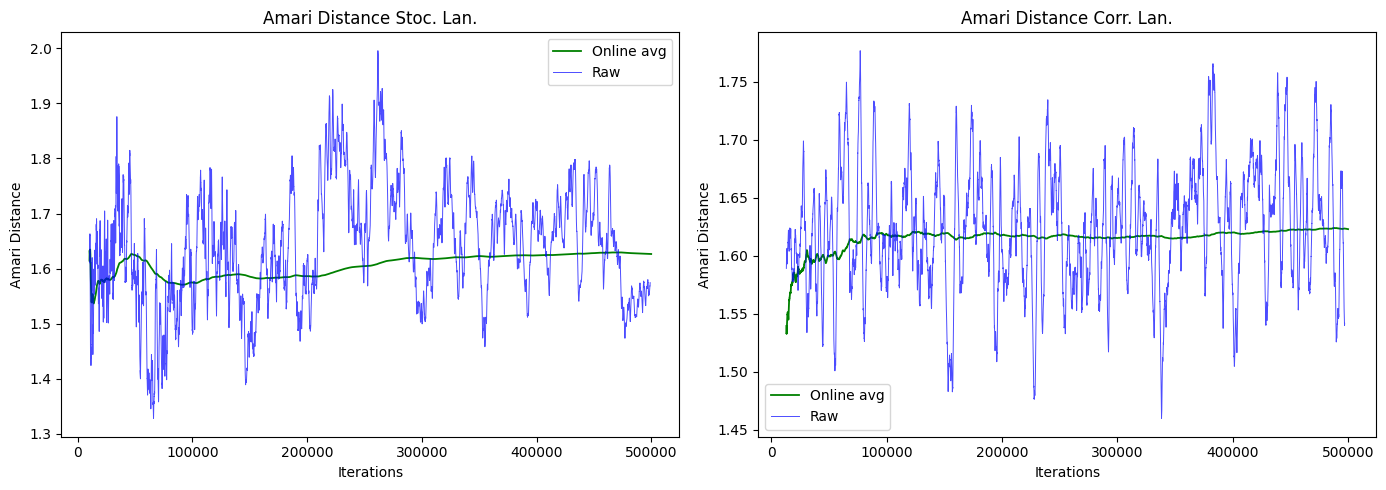

In [52]:
# amari distances
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ICA_exp.plot_amari_distances(samples_sgld, A, iters_sgld, experiment="Stoc. Lan.", ax=axes[0])
ICA_exp.plot_amari_distances(samples_corr, A, iters_corr, experiment="Corr. Lan.", ax=axes[1])
plt.tight_layout()
plt.show()

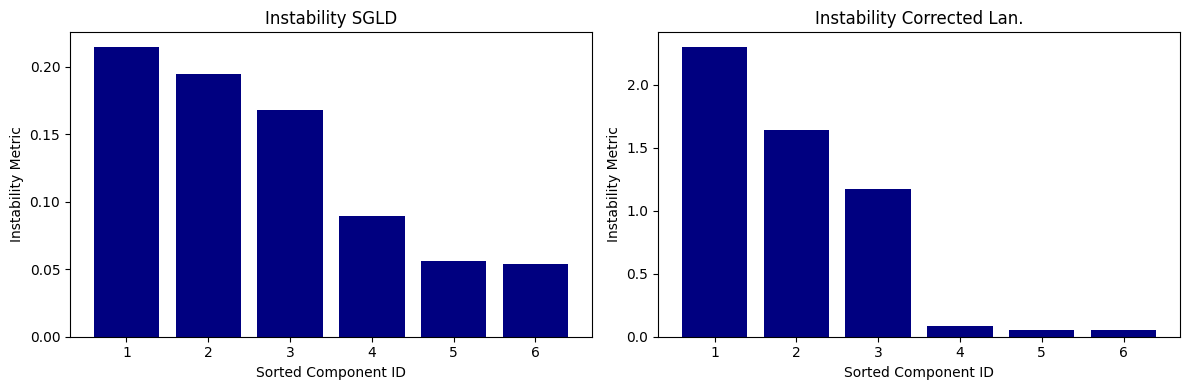

In [53]:
# instability
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ICA.plot_instability(samples_sgld, X, "Instability SGLD", ax=axes[0])
ICA.plot_instability(samples_corr, X, "Instability Corrected Lan.", ax=axes[1])
plt.tight_layout()
plt.show()

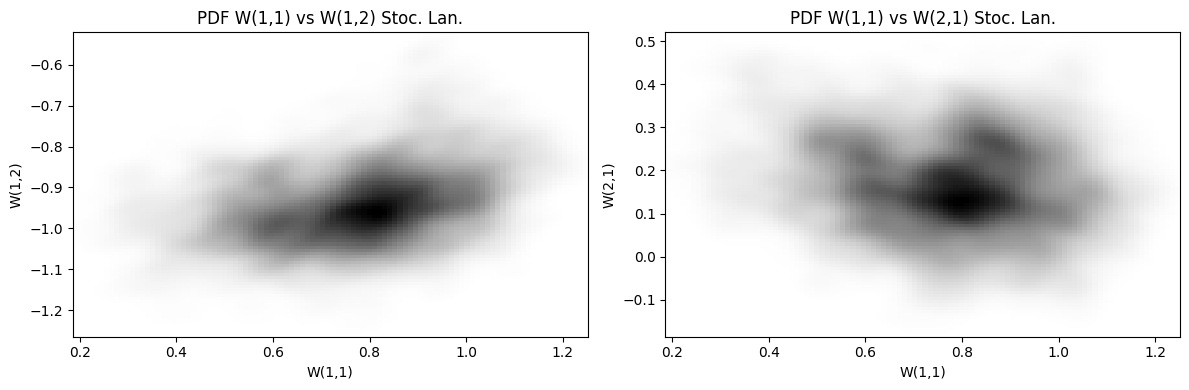

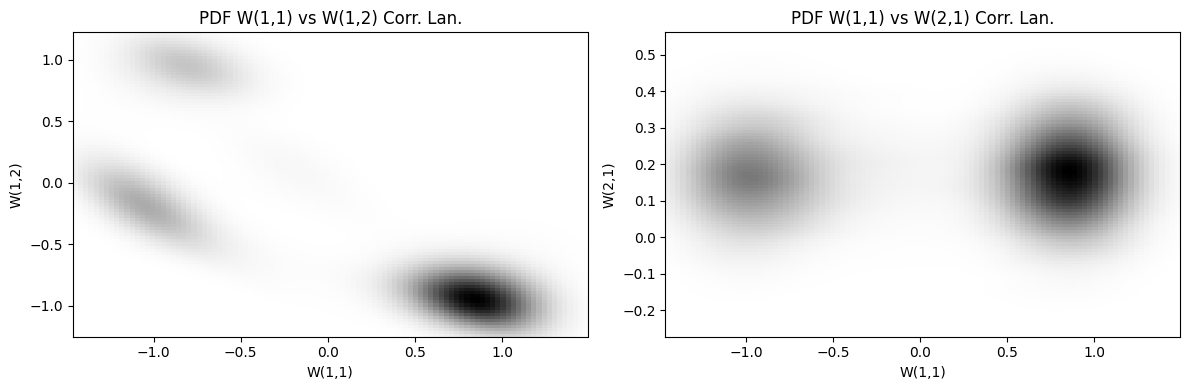

In [54]:
# 2d pdfs
ICA.plot_2d_pdfs(samples_sgld, "Stoc. Lan.")

ICA.plot_2d_pdfs(samples_corr, "Corr. Lan.")
